## SECTION 1 — TITLE AND OVERVIEW

# Apple’s Post-2011 Financial Strength and Stock-Risk Patterns

This notebook explores Apple's stock performance and financial characteristics after October 2011 (after Steve Jobs passed away). It aims to discover recurring monthly stock-market periods based on return, volatility, trading volume, and drawdown, and then use annual financial trends to explain the business conditions surrounding those periods. Problem 1 is an unsupervised pattern discovery task, while Problem 2 is descriptive interpretation.

**Disclaimer** This project does not predict Apple's future stock price and does not issue investment advice.

## SECTION 2 — IMPORT libs, LOAD FILES AND DOCUMENTATION

In this markdown I am importing libraries and it explains the process of loading the data files, including checking for their existence and displaying initial information.

This section also documents the stock and financial datasets used in the analysis and serves as a quick reference throughout the project. It summarizes each dataset’s filename, original source, expected columns, reporting frequency, and analysis period. A stock data column dictionary is also included to clarify key fields and definitions. By capturing this information upfront, the code promotes transparency, supports consistent analysis, and makes the overall workflow easier to understand, maintain, and reproduce.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

from google.colab import drive
drive.mount('/content/drive')

folder_path = '/content/drive/My Drive/ColabNotebooks/06FinalProject'
print(f"Accessing folder: {folder_path}")

# Define folder_path
folder_path = '/content/drive/My Drive/ColabNotebooks/06FinalProject'

stock_file = 'apple_stock_1980-2025.csv'
fundamentals_file = 'applefinancial_fundamentals_2011-2025.csv'

stock_file_path = os.path.join(folder_path, stock_file)
fundamentals_file_path = os.path.join(folder_path, fundamentals_file)

df_stock = None
df_fundamentals = None

print(f"Attempting to load stock data from: {stock_file_path}")
if os.path.exists(stock_file_path):
    try:
        df_stock = pd.read_csv(stock_file_path)
        print(f"Successfully loaded {stock_file}. Shape: {df_stock.shape}")
        print("First 5 rows of stock data:")
        print(df_stock.head())
        print("Column names and data types for stock data:")
        print(df_stock.info())
    except Exception as e:
        print(f"Error loading stock data: {e}")
else:
    print(f"Error: Stock file '{stock_file}' not found at '{stock_file_path}'")

print(f"\nAttempting to load financial fundamentals data from: {fundamentals_file_path}")
if os.path.exists(fundamentals_file_path):
    try:
        df_fundamentals = pd.read_csv(fundamentals_file_path)
        print(f"Successfully loaded {fundamentals_file}. Shape: {df_fundamentals.shape}")
        print("First 5 rows of financial fundamentals data:")
        print(df_fundamentals.head())
        print("Column names and data types for financial fundamentals data:")
        print(df_fundamentals.info())
    except Exception as e:
        print(f"Error loading financial fundamentals data: {e}")
else:
    print(f"Error: Financial fundamentals file '{fundamentals_file}' not found at '{fundamentals_file_path}'")


    column_dictionary_file = 'apple_stock_column_dictionary.csv'
column_dictionary_path = os.path.join(folder_path, column_dictionary_file)

print(f"\nChecking for column dictionary file: {column_dictionary_path}")
if os.path.exists(column_dictionary_path):
    try:
        df_column_dictionary = pd.read_csv(column_dictionary_path)
        print(f"Successfully loaded {column_dictionary_file}. Shape: {df_column_dictionary.shape}")
        print("Stock Column Dictionary:")
        print(df_column_dictionary)
    except Exception as e:
        print(f"Error loading column dictionary: {e}")
        # Create a placeholder if loading fails (loading failed few times and this helped)
        df_column_dictionary = pd.DataFrame({
            'Column Name': ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'],
            'Description': [
                'Date of the trading day',
                'Opening price of the stock',
                'Highest price during the day',
                'Lowest price during the day',
                'Closing price of the stock',
                'Adjusted closing price (accounts for splits, dividends, etc.)',
                'Number of shares traded'
            ]
        })
        print("Created a placeholder column dictionary as the file could not be loaded.")
        print(df_column_dictionary)
else:
    print(f"Column dictionary file '{column_dictionary_file}' not found. Creating a placeholder.")
    df_column_dictionary = pd.DataFrame({
        'Column Name': ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'],
        'Description': [
            'Date of the trading day',
            'Opening price of the stock',
            'Highest price during the day',
            'Lowest price during the day',
            'Closing price of the stock',
            'Adjusted closing price (accounts for splits, dividends, etc.)',
            'Number of shares traded'
        ]
    })
    print(df_column_dictionary)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Accessing folder: /content/drive/My Drive/ColabNotebooks/06FinalProject
Attempting to load stock data from: /content/drive/My Drive/ColabNotebooks/06FinalProject/apple_stock_1980-2025.csv
Successfully loaded apple_stock_1980-2025.csv. Shape: (11107, 7)
First 5 rows of stock data:
         Date  Adj Close     Close      High       Low      Open     Volume
0  1980-12-12   0.098834  0.128348  0.128906  0.128348  0.128348  469033600
1  1980-12-15   0.093678  0.121652  0.122210  0.121652  0.122210  175884800
2  1980-12-16   0.086802  0.112723  0.113281  0.112723  0.113281  105728000
3  1980-12-17   0.088951  0.115513  0.116071  0.115513  0.115513   86441600
4  1980-12-18   0.091530  0.118862  0.119420  0.118862  0.118862   73449600
Column names and data types for stock data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11107 entries, 0 to 11106
Data columns (

## SECTION 3 — DATA-QUALITY REVIEW

This section performs data quality checks and prepares the stock dataset for analysis. A working copy is created to preserve the original data, and the Date field is converted to a proper date format for accurate filtering and time-based analysis. The data is then sorted chronologically, duplicate records are removed, and observations are filtered to the selected analysis period beginning October 5, 2011.


Several validation checks help **confirm data reliability, including identifying missing values, duplicate dates, non-numeric fields, negative prices, inconsistent price ranges, and invalid trading volumes**. Essential columns required for return and price range analysis are reviewed, and records with critical missing values are removed. The cleaned dataset is then stored in a separate dataframe, providing a validated and analysis-ready version of the stock data.

In [ ]:
# Making a copy
df_stock_clean = df_stock.copy()

print("\n--- Stock Data Quality Checks ---")

# convert Date so I can filter and group the records correctly
df_stock_clean['Date'] = pd.to_datetime(df_stock_clean['Date'])
print(f"'Date' column converted to datetime. Data type: {df_stock_clean['Date'].dtype}")

# Sort by Date
df_stock_clean = df_stock_clean.sort_values(by='Date').reset_index(drop=True)
print("Data sorted by 'Date'.")

# Remove exact duplicate rows
duplicate_rows_before = df_stock_clean.duplicated().sum()
if duplicate_rows_before > 0:
    df_stock_clean.drop_duplicates(inplace=True)
    print(f"Removed {duplicate_rows_before} exact duplicate rows.")
else:
    print("No exact duplicate rows found.")

# Filter to Date >= 2011-10-05
initial_rows = df_stock_clean.shape[0]
filter_date = '2011-10-05'
df_stock_clean = df_stock_clean[df_stock_clean['Date'] >= filter_date].reset_index(drop=True)
remaining_rows = df_stock_clean.shape[0]
print(f"Filtered data to '{filter_date}' onward. {remaining_rows} observations remain (down from {initial_rows}).")

# Check for missing values
print("\nMissing values per column after filtering:")
print(df_stock_clean.isnull().sum())

# Check for duplicate dates
duplicate_dates = df_stock_clean['Date'].duplicated().sum()
if duplicate_dates > 0:
    print(f"Found {duplicate_dates} duplicate dates. Inspecting first few:")
    print(df_stock_clean[df_stock_clean['Date'].duplicated(keep=False)].sort_values('Date').head())
else:
    print("No duplicate dates found.")

# Check for numeric values stored as text (already handled by df.info() and to_datetime, but re-check for other cols)

for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
    if not pd.api.types.is_numeric_dtype(df_stock_clean[col]):
        print(f"Warning: Column '{col}' is not numeric. Attempting conversion.")
        df_stock_clean[col] = pd.to_numeric(df_stock_clean[col], errors='coerce')

# Check for negative prices
negative_prices = df_stock_clean[['Open', 'High', 'Low', 'Close', 'Adj Close']].lt(0).sum().sum()
if negative_prices > 0:
    print(f"Warning: Found {negative_prices} instances of negative prices. Inspecting first few:")
    print(df_stock_clean[(df_stock_clean[['Open', 'High', 'Low', 'Close', 'Adj Close']] < 0).any(axis=1)].head())
else:
    print("No negative prices found.")

# Check for High values lower than Low values
invalid_high_low = df_stock_clean[df_stock_clean['High'] < df_stock_clean['Low']].shape[0]
if invalid_high_low > 0:
    print(f"Warning: Found {invalid_high_low} rows where 'High' is less than 'Low'. Inspecting first few:")
    print(df_stock_clean[df_stock_clean['High'] < df_stock_clean['Low']].head())
else:
    print("No instances where 'High' is less than 'Low'.")

# Check for Open or Close outside the High-Low range
invalid_open_close = df_stock_clean[((df_stock_clean['Open'] < df_stock_clean['Low']) | (df_stock_clean['Open'] > df_stock_clean['High'])) |
                                    ((df_stock_clean['Close'] < df_stock_clean['Low']) | (df_stock_clean['Close'] > df_stock_clean['High']))].shape[0]
if invalid_open_close > 0:
    print(f"Warning: Found {invalid_open_close} rows where 'Open' or 'Close' is outside the 'High'-'Low' range. Inspecting first few:")
    print(df_stock_clean[((df_stock_clean['Open'] < df_stock_clean['Low']) | (df_stock_clean['Open'] > df_stock_clean['High'])) |
                                    ((df_stock_clean['Close'] < df_stock_clean['Low']) | (df_stock_clean['Close'] > df_stock_clean['High']))].head())
else:
    print("No 'Open' or 'Close' values outside the 'High'-'Low' range.")

# Check for zero or negative volume
zero_neg_volume = df_stock_clean[df_stock_clean['Volume'] <= 0].shape[0]
if zero_neg_volume > 0:
    print(f"Found {zero_neg_volume} rows with zero or negative 'Volume'. These rows are flagged for review, not removed.")
    # Display examples
    print(df_stock_clean[df_stock_clean['Volume'] <= 0].head())
else:
    print("No zero or negative 'Volume' found.")


# For stock data, 'Adj Close' is essential for returns, 'High'/'Low' for range.
initial_shape = df_stock_clean.shape
df_stock_clean.dropna(subset=['Adj Close', 'High', 'Low'], inplace=True)
if df_stock_clean.shape[0] < initial_shape[0]:
    print(f"Dropped {initial_shape[0] - df_stock_clean.shape[0]} rows due to missing essential values ('Adj Close', 'High', 'Low').")

print(f"Current shape of cleaned stock data: {df_stock_clean.shape}")

# Storing cleaned dataframe in a new variable
df_stock_processed = df_stock_clean.copy()



--- Stock Data Quality Checks ---
'Date' column converted to datetime. Data type: datetime64[ns]
Data sorted by 'Date'.
No exact duplicate rows found.
Filtered data to '2011-10-05' onward. 3333 observations remain (down from 11107).

Missing values per column after filtering:
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
No duplicate dates found.
No negative prices found.
No instances where 'High' is less than 'Low'.
No 'Open' or 'Close' values outside the 'High'-'Low' range.
No zero or negative 'Volume' found.
Current shape of cleaned stock data: (3333, 7)


In [ ]:
df_fundamentals_clean = df_fundamentals.copy()

print("\n--- Financial Fundamentals Data Quality Checks ---")

# Normalize column names (make them easier to use in Python)
original_columns = df_fundamentals_clean.columns.tolist()
normalized_columns = [
    col.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('.', '')
    for col in original_columns
]
column_name_mapping = dict(zip(original_columns, normalized_columns))
df_fundamentals_clean.rename(columns=column_name_mapping, inplace=True)
print("Column names normalized. Mapping:")
for original, normalized in column_name_mapping.items():
    print(f"  '{original}' -> '{normalized}'")

# Confirm Years run from 2011 to 2025
if 'year' in df_fundamentals_clean.columns:
    min_year = df_fundamentals_clean['year'].min()
    max_year = df_fundamentals_clean['year'].max()
    print(f"'Year' column ranges from {min_year} to {max_year}.")
    if min_year > 2011 or max_year < 2025:
        print(f"Warning: Year range (2011-2025) is not fully covered by data ({min_year}-{max_year}).")
else:
    print("Warning: 'Year' column not found in financial fundamentals data.")

# Check for missing values
print("\nMissing values per column:")
print(df_fundamentals_clean.isnull().sum())

# Check for duplicate years
duplicate_years = df_fundamentals_clean['year'].duplicated().sum()
if duplicate_years > 0:
    print(f"Warning: Found {duplicate_years} duplicate years. Inspecting first few:")
    print(df_fundamentals_clean[df_fundamentals_clean['year'].duplicated(keep=False)].sort_values('year').head())
else:
    print("No duplicate years found.")

# Check if numeric values are stored as text (using df.info() check first, then coerce)
for col in ['revenue', 'operating_income', 'net_income', 'free_cash_flow', 'operating_cash_flow', 'capital_expenditures', 'total_debt', 'cash_and_investments', 'diluted_shares_outstanding', 'eps_diluted', 'dividends_per_share', 'share_repurchases']:
    if col in df_fundamentals_clean.columns and not pd.api.types.is_numeric_dtype(df_fundamentals_clean[col]):
        print(f"Warning: Column '{col}' is not numeric. Attempting conversion.")
        # Convert to numeric, coercing errors will turn non-numeric into NaN
        df_fundamentals_clean[col] = pd.to_numeric(df_fundamentals_clean[col], errors='coerce')
        if df_fundamentals_clean[col].isnull().sum() > 0:
            print(f"  After conversion, {df_fundamentals_clean[col].isnull().sum()} null values introduced in '{col}'.")


# Recalculate Free Cash Flow and compare with supplied value
# Free cash flow equals Operating cash flow minus Capital expenditures
required_cols_fcf = ['operating_cash_flow', 'capital_expenditures', 'free_cash_flow']
if all(col in df_fundamentals_clean.columns for col in required_cols_fcf):
    df_fundamentals_clean['recalculated_free_cash_flow'] = df_fundamentals_clean['operating_cash_flow'] - df_fundamentals_clean['capital_expenditures']

    # Compare and report differences
    fcf_differences = df_fundamentals_clean[df_fundamentals_clean['free_cash_flow'].round(2) != df_fundamentals_clean['recalculated_free_cash_flow'].round(2)]

    if not fcf_differences.empty:
        print("\nWarning: Differences found between 'free_cash_flow' and 'recalculated_free_cash_flow'.")
        print("Displaying years with discrepancies:")
        print(fcf_differences[['year', 'free_cash_flow', 'recalculated_free_cash_flow']])
    else:
        print("\n'Free Cash Flow' matches 'Operating Cash Flow' - 'Capital Expenditures'.")
else:
    missing_fcf_cols = [col for col in required_cols_fcf if col not in df_fundamentals_clean.columns]
    print(f"Warning: Cannot verify Free Cash Flow; missing one or more required columns: {missing_fcf_cols}")

# Drop the recalculated FCF column if it's not needed later
if 'recalculated_free_cash_flow' in df_fundamentals_clean.columns:
    df_fundamentals_clean.drop(columns=['recalculated_free_cash_flow'], inplace=True)

print(f"\nCleaned financial fundamentals data shape: {df_fundamentals_clean.shape}")

# Store the cleaned dataframe for later use
df_fundamentals_processed = df_fundamentals_clean.copy()



--- Financial Fundamentals Data Quality Checks ---
Column names normalized. Mapping:
  'Year' -> 'year'
  'Revenue' -> 'revenue'
  'Net income' -> 'net_income'
  'Operating income' -> 'operating_income'
  'Operating cash flow' -> 'operating_cash_flow'
  'Capital expenditures' -> 'capital_expenditures'
  'Free cash flow' -> 'free_cash_flow'
  'Cash and investments' -> 'cash_and_investments'
  'Total debt' -> 'total_debt'
  'Total assets' -> 'total_assets'
  'Shareholders equity' -> 'shareholders_equity'
  'Diluted shares' -> 'diluted_shares'
  'Earnings per share' -> 'earnings_per_share'
  'Dividends' -> 'dividends'
  'Share repurchases' -> 'share_repurchases'
'Year' column ranges from 2011 to 2025.

Missing values per column:
year                    0
revenue                 0
net_income              0
operating_income        0
operating_cash_flow     0
capital_expenditures    0
free_cash_flow          0
cash_and_investments    0
total_debt              0
total_assets            0
sha

This Markdown cell provides an interpretation of the data quality review findings, explaining their implications for the project.

## SECTION 4 — FEATURE ENGINEERING

This section creates a set of daily market indicators that will be used for exploratory analysis and clustering. I **calculate key return measures**, including daily percentage returns and logarithmic returns, to capture stock price movements from one trading day to the next.

To better **understand market behavior over time**, rolling and cumulative indicators are generated. These include 21-day volatility, rolling peak prices, drawdown from historical highs, average trading volume, and relative volume strength. Using **these features helps transform raw stock prices into meaningful signals that highlight return patterns, volatility,** market trends, and changes in trading activity, creating a richer dataset for downstream analysis.

In [ ]:
df = df_stock_processed.copy()

print("Calculating daily features...")

# Daily_Return: Adj Close percentage change
df['Daily_Return'] = df['Adj Close'].pct_change()

# Log_Return: Natural log of current Adjusted Close divided by previous Adjusted Close.
df['Log_Return'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))

# Intraday_Range: (High - Low) / Open.
df['Intraday_Range'] = (df['High'] - df['Low']) / df['Open']


# I keep monthly observations so daily noise does not dominate the clusters.
df['Rolling_Volatility_21D'] = df['Daily_Return'].rolling(window=21).std() * np.sqrt(252)

# Rolling_Maximum: Cumulative maximum of Adjusted Close from the beginning of the filtered period.
df['Rolling_Maximum'] = df['Adj Close'].expanding().max()

# Drawdown: Adj Close / Rolling_Maximum
df['Drawdown'] = df['Adj Close'] / df['Rolling_Maximum'] - 1

# Volume_21D_Average: 21-day rolling average of Volume
df['Volume_21D_Average'] = df['Volume'].rolling(window=21).mean()

# Volume_Ratio: Volume / Volume_21D_Average
df['Volume_Ratio'] = df['Volume'] / df['Volume_21D_Average']

print("Daily features calculated.")
print("First 5 rows with new features:")
print(df.head())


Calculating daily features...
Daily features calculated.
First 5 rows with new features:
        Date  Adj Close      Close       High        Low       Open  \
0 2011-10-05  11.395420  13.508929  13.565000  12.867857  13.137857   
1 2011-10-06  11.368907  13.477500  13.742143  13.278571  13.333214   
2 2011-10-07  11.140848  13.207143  13.490714  13.160357  13.420714   
3 2011-10-10  11.713554  13.886071  13.886071  13.507500  13.538929   
4 2011-10-11  12.059410  14.296071  14.399286  13.982143  14.020357   

      Volume  Daily_Return  Log_Return  Intraday_Range  \
0  786469600           NaN         NaN        0.053064   
1  812582400     -0.002327   -0.002329        0.034768   
2  535458000     -0.020060   -0.020264        0.024615   
3  442514800      0.051406    0.050128        0.027962   
4  605687600      0.029526    0.029099        0.029753   

   Rolling_Volatility_21D  Rolling_Maximum  Drawdown  Volume_21D_Average  \
0                     NaN        11.395420  0.000000       

Over here I am summarizing results of the feature engineering process and explains the impact of newly created metrics on the dataset. It highlights rows with missing values that were introduced by calculations such as rolling averages, volatility measures, and lag-based returns, where prior observations are required.

In [ ]:
initial_rows = df.shape[0]
# Identify columns that are likely to have NaNs
features_with_nans = [
    'Daily_Return',
    'Log_Return',
    'Intraday_Range',
    'Rolling_Volatility_21D',
    'Drawdown',
    'Volume_Ratio'
]

# Drop rows where any of these critical features are NaN
df.dropna(subset=features_with_nans, inplace=True)

rows_removed = initial_rows - df.shape[0]
print(f"Removed {rows_removed} rows containing NaN values introduced by feature engineering.")
print(f"Remaining rows: {df.shape[0]}")

df_daily_features = df.copy()


Removed 21 rows containing NaN values introduced by feature engineering.
Remaining rows: 3312


## SECTION 5 — DAILY STOCK EXPLORATORY ANALYSIS

This section presents the exploratory data analysis (EDA) performed on the daily stock dataset. I use visualizations and summary statistics to **examine key aspects of stock performance, including price movements, daily returns, volatility, drawdowns, and trading volume.** The analysis helps identify trends, patterns, variability, and potential anomalies within the data. These insights provide a stronger understanding of market behavior and establish a solid foundation for subsequent analysis, feature evaluation, and modeling activities.

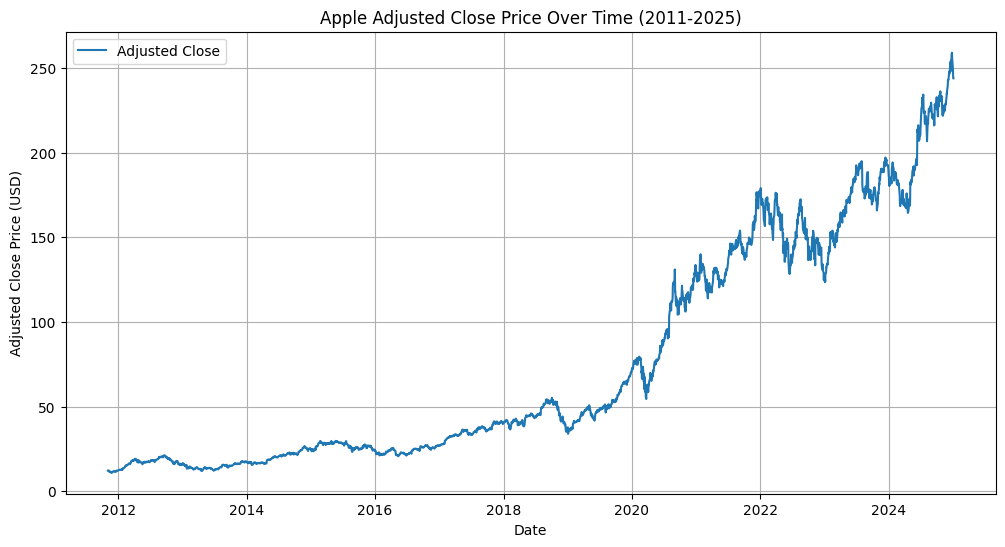

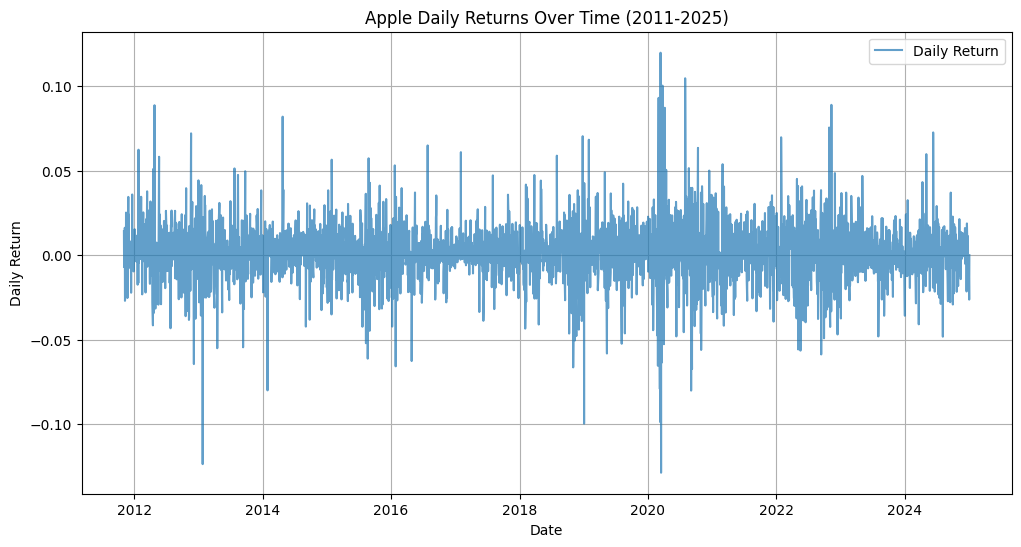

In [ ]:
# 1. Adjusted Close over time
plt.figure(figsize=(12, 6))
plt.plot(df_daily_features['Date'], df_daily_features['Adj Close'], label='Adjusted Close')
plt.title('Apple Adjusted Close Price Over Time (2011-2025)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price (USD)')
plt.grid(True)
plt.legend()
plt.show()

# 2. Daily returns over time
plt.figure(figsize=(12, 6))
plt.plot(df_daily_features['Date'], df_daily_features['Daily_Return'], label='Daily Return', alpha=0.7)
plt.title('Apple Daily Returns Over Time (2011-2025)')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)
plt.legend()
plt.show()

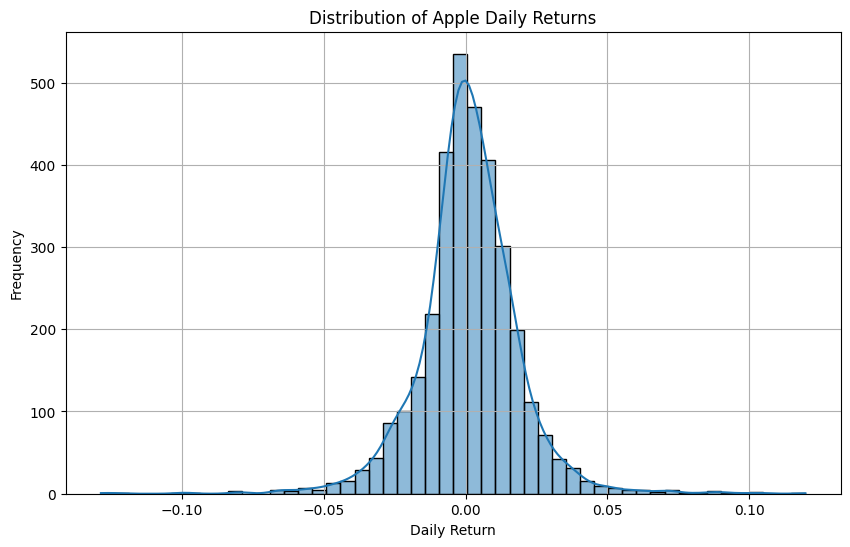

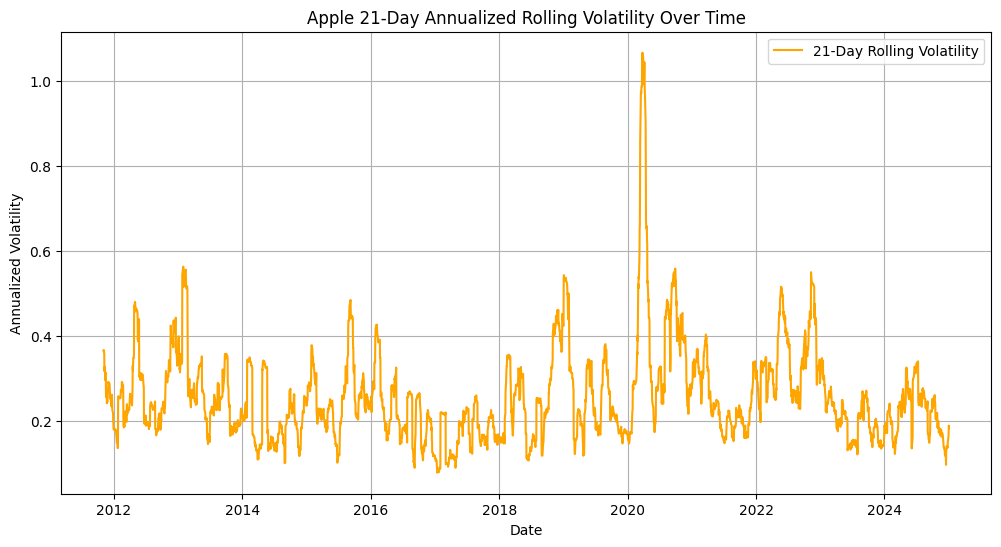

In [ ]:
# 3. Distribution of daily returns
plt.figure(figsize=(10, 6))
sns.histplot(df_daily_features['Daily_Return'].dropna(), bins=50, kde=True)
plt.title('Distribution of Apple Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 4. Rolling volatility over time
plt.figure(figsize=(12, 6))
plt.plot(df_daily_features['Date'], df_daily_features['Rolling_Volatility_21D'], label='21-Day Rolling Volatility', color='orange')
plt.title('Apple 21-Day Annualized Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.grid(True)
plt.legend()
plt.show()

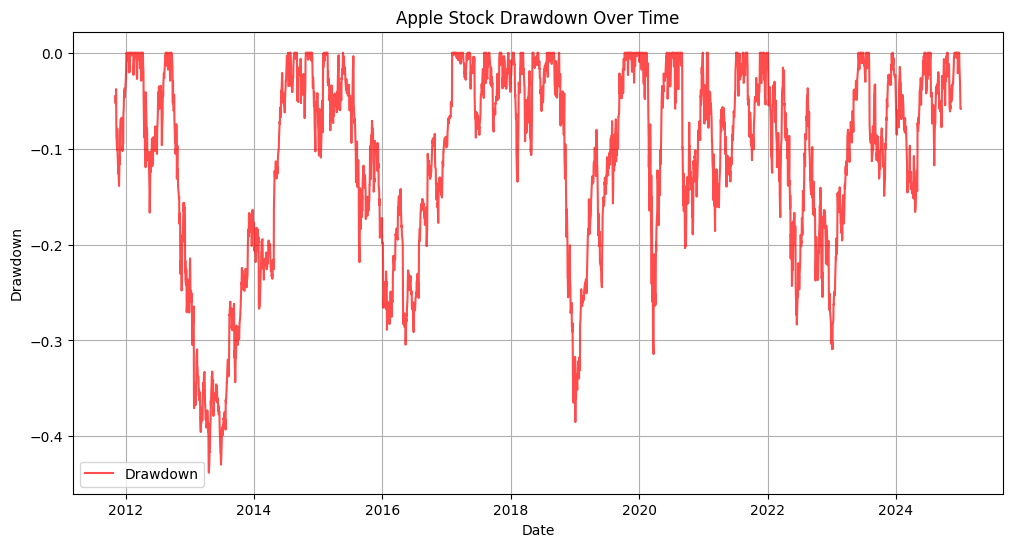

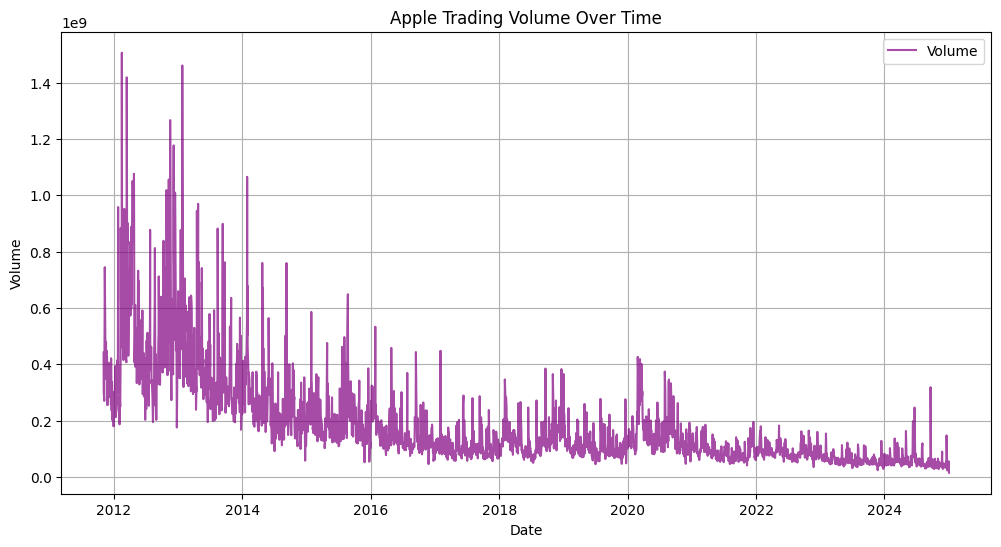

In [ ]:
# 5. Drawdown over time
plt.figure(figsize=(12, 6))
plt.plot(df_daily_features['Date'], df_daily_features['Drawdown'], label='Drawdown', color='red', alpha=0.7)
plt.title('Apple Stock Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.grid(True)
plt.legend()
plt.show()

# 6. Trading volume over time
plt.figure(figsize=(12, 6))
plt.plot(df_daily_features['Date'], df_daily_features['Volume'], label='Volume', color='purple', alpha=0.7)
plt.title('Apple Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Calculate and display summary statistics
print("\n--- Daily Stock Performance Summary Statistics ---")

# Mean and median daily return
mean_return = df_daily_features['Daily_Return'].mean()
median_return = df_daily_features['Daily_Return'].median()
print(f"Mean Daily Return: {mean_return:.6f}")
print(f"Median Daily Return: {median_return:.6f}")

# Standard deviation of daily return
std_dev_return = df_daily_features['Daily_Return'].std()
print(f"Standard Deviation of Daily Return (Volatility): {std_dev_return:.6f}")

# Best and worst daily returns
best_return = df_daily_features['Daily_Return'].max()
worst_return = df_daily_features['Daily_Return'].min()
best_return_date = df_daily_features.loc[df_daily_features['Daily_Return'].idxmax(), 'Date']
worst_return_date = df_daily_features.loc[df_daily_features['Daily_Return'].idxmin(), 'Date']
print(f"Best Daily Return: {best_return:.6f} on {best_return_date.strftime('%Y-%m-%d')}")
print(f"Worst Daily Return: {worst_return:.6f} on {worst_return_date.strftime('%Y-%m-%d')}")

# Maximum drawdown
max_drawdown = df_daily_features['Drawdown'].min()
max_drawdown_date = df_daily_features.loc[df_daily_features['Drawdown'].idxmin(), 'Date']
print(f"Maximum Drawdown: {max_drawdown:.6f} on {max_drawdown_date.strftime('%Y-%m-%d')}")

# Highest rolling volatility and its date
highest_volatility = df_daily_features['Rolling_Volatility_21D'].max()
highest_volatility_date = df_daily_features.loc[df_daily_features['Rolling_Volatility_21D'].idxmax(), 'Date']
print(f"Highest 21-Day Rolling Volatility: {highest_volatility:.6f} on {highest_volatility_date.strftime('%Y-%m-%d')}")



--- Daily Stock Performance Summary Statistics ---
Mean Daily Return: 0.001066
Median Daily Return: 0.000903
Standard Deviation of Daily Return (Volatility): 0.017655
Best Daily Return: 0.119808 on 2020-03-13
Worst Daily Return: -0.128647 on 2020-03-16
Maximum Drawdown: -0.437972 on 2013-04-19
Highest 21-Day Rolling Volatility: 1.066534 on 2020-03-26


This cell interprets the calculated summary statistics, highlighting extreme values and their potential significance for understanding Apple's stock behavior.

## SECTION 6 — MONTHLY ANALYTICAL DATASET

This section explains the reasoning behind converting daily stock data into monthly observations for analysis. I **aggregate the data at the monthly level to reduce the influence of short-term market fluctuations and daily noise** that may obscure broader patterns. This approach creates more stable and meaningful market periods, making it easier to compare performance across time. The resulting dataset provides a clearer foundation for clustering.

In [ ]:
print("Aggregating daily data into monthly observations...")

df_monthly = df_daily_features.copy()

# Extract Year and Month for grouping
df_monthly['Year'] = df_monthly['Date'].dt.year
df_monthly['Month'] = df_monthly['Date'].dt.month

# Group by Year and Month
monthly_groups = df_monthly.groupby(['Year', 'Month'])

# Calculate monthly features
monthly_return = monthly_groups['Adj Close'].apply(lambda x: (x.iloc[-1] / x.iloc[0]) - 1)

# Monthly_Volatility: Standard deviation of daily returns within the month,.
monthly_volatility = monthly_groups['Daily_Return'].std() * np.sqrt(252)

# Average_Drawdown: Mean daily drawdown during the month
average_drawdown = monthly_groups['Drawdown'].mean()

# Worst_Drawdown: Minimum daily drawdown during the month
worst_drawdown = monthly_groups['Drawdown'].min()

# Avg_Volume_Ratio: Mean daily Volume_Ratio during the month
average_volume_ratio = monthly_groups['Volume_Ratio'].mean()

# Ave_Intraday_Range: Mean daily Intraday_Range during the month
average_intraday_range = monthly_groups['Intraday_Range'].mean()

# Retain other relevant monthly information
month_start = monthly_groups['Date'].min()
month_end = monthly_groups['Date'].max()
ending_adjusted_close = monthly_groups['Adj Close'].last()

# Combine all monthly features into a new DataFrame
df_monthly_analytical = pd.DataFrame({
    'Month_Start': month_start,
    'Month_End': month_end,
    'Ending_Adjusted_Close': ending_adjusted_close,
    'Monthly_Return': monthly_return,
    'Monthly_Volatility': monthly_volatility,
    'Average_Drawdown': average_drawdown,
    'Worst_Drawdown': worst_drawdown,
    'Average_Volume_Ratio': average_volume_ratio,
    'Average_Intraday_Range': average_intraday_range
}).reset_index()

print("Monthly analytical dataset created.")


Aggregating daily data into monthly observations...
Monthly analytical dataset created.


In [ ]:
print("\nFirst 5 rows of the monthly analytical dataset:")
print(df_monthly_analytical.head())

print("\nSummary statistics for the monthly analytical dataset:")
print(df_monthly_analytical.describe())

# Check for missing values
print("\nMissing values in monthly analytical dataset:")
print(df_monthly_analytical.isnull().sum())

# Check for infinite values (can result from division by zero)
print("\nInfinite values in monthly analytical dataset:")
for col in df_monthly_analytical.columns:
    if df_monthly_analytical[col].dtype in ['float64', 'int64']:
        num_inf = df_monthly_analytical[col].isin([np.inf, -np.inf]).sum()
        if num_inf > 0:
            print(f"  {col}: {num_inf}")

# Drop any rows with NaN values introduced during aggregation/calculation if any
initial_monthly_rows = df_monthly_analytical.shape[0]
df_monthly_analytical.dropna(inplace=True)
if df_monthly_analytical.shape[0] < initial_monthly_rows:
    print(f"Dropped {initial_monthly_rows - df_monthly_analytical.shape[0]} rows due to missing values in the monthly analytical dataset.")

df_monthly_features = df_monthly_analytical.copy()


First 5 rows of the monthly analytical dataset:
   Year  Month Month_Start  Month_End  Ending_Adjusted_Close  Monthly_Return  \
0  2011     11  2011-11-03 2011-11-30              11.514417       -0.051778   
1  2011     12  2011-12-01 2011-12-30              12.201303        0.044002   
2  2012      1  2012-01-03 2012-01-31              13.752233        0.110036   
3  2012      2  2012-02-01 2012-02-29              16.341921        0.189066   
4  2012      3  2012-03-01 2012-03-30              18.062452        0.101163   

   Monthly_Volatility  Average_Drawdown  Worst_Drawdown  Average_Volume_Ratio  \
0            0.299306         -0.091662       -0.138949              0.881050   
1            0.179422         -0.069414       -0.102548              0.812536   
2            0.259476         -0.006253       -0.026075              1.175609   
3            0.192375         -0.002945       -0.023142              1.277917   
4            0.241040         -0.007741       -0.029258          

This cell interprets the monthly aggregated data and summary statistics, confirming data readiness for clustering and noting any remaining data quality considerations.

## SECTION 7 — TECHNIQUE SELECTION AND JUSTIFICATION???

This section outlines the reasoning behind the selected unsupervised learning approach and the preparation steps required before clustering. I u**se K-Means because it is an effective and interpretable method for identifying groups of observations with similar market characteristics**. Feature scaling is applied to ensure that variables measured on different ranges contribute equally to the clustering process. By **clustering monthly features** rather than daily observations, the **analysis focuses on broader market conditions and reduces short-term noise**. The **silhouette score is used as an exploratory measure to help assess cluster quality** and guide the selection of an appropriate number of clusters.

## SECTION 8 — PREPARE FEATURES FOR CLUSTERING

This cell specifies the features selected for clustering, explaining why certain variables are included (e.g., return, volatility) and others are excluded (e.g., year, raw price) to avoid misleading cluster interpretations.

In [ ]:
print("Preparing features for clustering...")

# Define the features to be used for clustering
clustering_features = [
    'Monthly_Return',
    'Monthly_Volatility',
    'Average_Drawdown',
    'Worst_Drawdown',
    'Average_Volume_Ratio',
    'Average_Intraday_Range'
]

# Extract the features from the monthly analytical DataFrame
X = df_monthly_features[clustering_features]

# Initialize StandardScaler
# I scale the features because they use different units.
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features, index=X.index)

print("Features scaled successfully.")

# Display a small table showing the mean and standard deviation of the scaled features
print("\nMean of scaled features (should be close to 0):")
print(X_scaled_df.mean().round(2))

print("\nStandard deviation of scaled features (should be close to 1):")
print(X_scaled_df.std().round(2))


Preparing features for clustering...
Features scaled successfully.

Mean of scaled features (should be close to 0):
Monthly_Return           -0.0
Monthly_Volatility       -0.0
Average_Drawdown          0.0
Worst_Drawdown            0.0
Average_Volume_Ratio      0.0
Average_Intraday_Range    0.0
dtype: float64

Standard deviation of scaled features (should be close to 1):
Monthly_Return            1.0
Monthly_Volatility        1.0
Average_Drawdown          1.0
Worst_Drawdown            1.0
Average_Volume_Ratio      1.0
Average_Intraday_Range    1.0
dtype: float64


## SECTION 9 — SELECT THE NUMBER OF CLUSTERS

This section describes the approach used to determine the **optimal number of clusters (k) for the K-Means** algorithm. I evaluate different cluster configurations using the silhouette score, which helps measure how well observations **fit within their assigned clusters** while remaining distinct from others. Cluster sizes and stakeholder interpretability are also considered to ensure the results are both statistically meaningful and practical to explain.

The analysis then interprets the silhouette score trends alongside the distribution of observations across clusters. This approach helps ensure that the **resulting clusters represent meaningful market regimes **that can be effectively analyzed and communicated.

Evaluating K-Means for k values from 2 through 6...
K-Means evaluation complete.

K-Means Evaluation Results:
   k  Silhouette_Score            Cluster_Sizes
0  2          0.346210                [113, 46]
1  3          0.322517             [34, 30, 95]
2  4          0.239384         [37, 25, 65, 32]
3  5          0.231249     [27, 36, 20, 49, 27]
4  6          0.230384  [49, 33, 29, 27, 1, 20]


/tmp/ipykernel_528/1361609873.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  k_results = pd.concat([


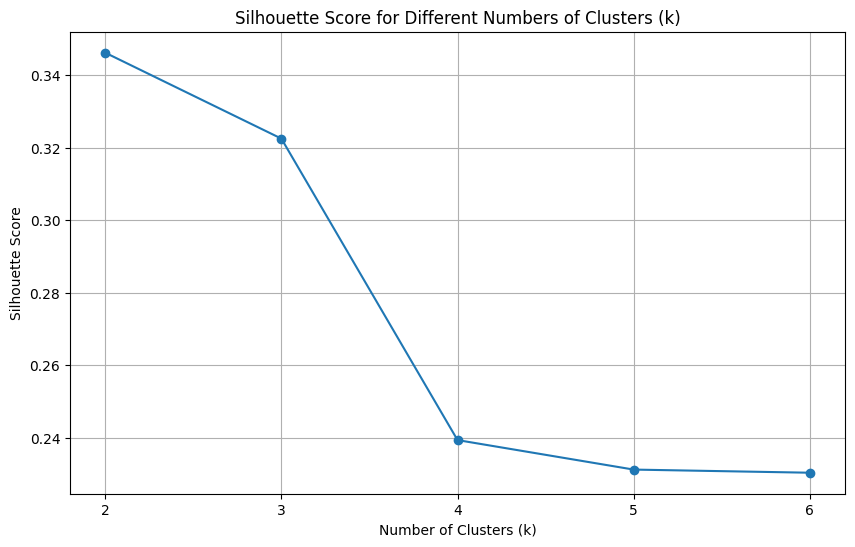

In [ ]:
print("Evaluating K-Means for k values from 2 through 6...")

inertia = []
silhouette_scores = []
k_values = range(2, 7) # k from 2 to 6

k_results = pd.DataFrame(columns=['k', 'Silhouette_Score', 'Cluster_Sizes'])

for k in k_values:
    # testing several cluster counts instead of choosing one without evidence.
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is set to 10 for reproducibility
    kmeans.fit(X_scaled)

    # Calculate inertia -optional
    inertia.append(kmeans.inertia_)

    # Calculate the silhouette score
    # silhouette score is an exploratory guide rather than proof that the clusters are objectively correct.
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

    # Get cluster sizes
    cluster_labels = pd.Series(kmeans.labels_)
    sizes = cluster_labels.value_counts().sort_index().tolist()

    # Store results in the DataFrame
    k_results = pd.concat([
        k_results,
        pd.DataFrame([{'k': k, 'Silhouette_Score': score, 'Cluster_Sizes': sizes}])
    ], ignore_index=True)

print("K-Means evaluation complete.")

print("\nK-Means Evaluation Results:")
print(k_results)

# Plot k against the silhouette score
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score for Different Numbers of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()


This Markdown cell interprets the silhouette score plot and cluster sample sizes, justifying the final chosen value for k based on the trade-offs between statistical performance and practical interpretability.

## SECTION 10 — FINAL K-MEANS MODEL

This section describes the development of the final K-Means clustering model using the selected number of clusters. I **fit the model to the prepared monthly dataset and examine the resulting cluster characteristics,** including cluster sizes, average and median feature values, and the time periods represented within each group.

The cluster profiles are then interpreted using return, volatility, drawdown, and trading volume metrics. To **make the findings easier for stakeholders to understand, descriptive names are assigned** to each cluster based on their dominant characteristics. These labels transform the technical clustering output into meaningful market regimes that support clearer communication and business interpretation.

In [ ]:
# choosing k=3 for example
chosen_k = 3

print(f"Fitting final K-Means model with k = {chosen_k} clusters...")

# Fit K-Means using the chosen k
final_kmeans_model = KMeans(n_clusters=chosen_k, random_state=42, n_init=10) # n_init is set to 10 for reproducibility and robustness
final_kmeans_model.fit(X_scaled)

# Add the cluster number to the monthly dataset
df_monthly_features['kmeans_cluster'] = final_kmeans_model.labels_

print("Final K-Means model fitted and clusters assigned to monthly dataset.")


# display Number of months in each cluster
cluster_counts = df_monthly_features['kmeans_cluster'].value_counts().sort_index()
print("\nNumber of months in each cluster:")
print(cluster_counts)

# display Percentage of months..
cluster_percentages = df_monthly_features['kmeans_cluster'].value_counts(normalize=True).sort_index() * 100
print("\nPercentage of months in each cluster:")
print(cluster_percentages.round(2))


Fitting final K-Means model with k = 3 clusters...
Final K-Means model fitted and clusters assigned to monthly dataset.

Number of months in each cluster:
kmeans_cluster
0    34
1    30
2    95
Name: count, dtype: int64

Percentage of months in each cluster:
kmeans_cluster
0    21.38
1    18.87
2    59.75
Name: proportion, dtype: float64


In [ ]:
print("\n--- Cluster Profiles (Mean of Original Unscaled Features) ---")
# I will sort the cluster summary by risk or volatility rather than assuming cluster 0 is the safest.
# Using Monthly_Volatility as the primary sorting key.
cluster_means = df_monthly_features.groupby('kmeans_cluster')[clustering_features].mean().sort_values(by='Monthly_Volatility')
print(cluster_means)

print("\n--- Cluster Profiles (Median of Original Unscaled Features) ---")
cluster_medians = df_monthly_features.groupby('kmeans_cluster')[clustering_features].median().loc[cluster_means.index] # Maintain sort order
print(cluster_medians)

print("\n--- Earliest and Latest Month in Each Cluster ---")
cluster_dates = df_monthly_features.groupby('kmeans_cluster').agg(
    Earliest_Month=('Month_Start', 'min'),
    Latest_Month=('Month_End', 'max')
).loc[cluster_means.index] # Maintain sort order
print(cluster_dates)

print("\n--- Five Example Months from Each Cluster (Sorted by Volatility) ---")
for cluster_id in cluster_means.index:
    print(f"\nCluster {cluster_id} Examples:")
    example_months = df_monthly_features[df_monthly_features['kmeans_cluster'] == cluster_id].sample(n=min(5, len(df_monthly_features[df_monthly_features['kmeans_cluster'] == cluster_id])), random_state=42)
    print(example_months[['Month_Start', 'Ending_Adjusted_Close', 'Monthly_Return', 'Monthly_Volatility', 'Worst_Drawdown']])



--- Cluster Profiles (Mean of Original Unscaled Features) ---
                Monthly_Return  Monthly_Volatility  Average_Drawdown  \
kmeans_cluster                                                         
2                     0.035442            0.207513         -0.046804   
0                     0.057622            0.255197         -0.238459   
1                    -0.077412            0.411200         -0.152216   

                Worst_Drawdown  Average_Volume_Ratio  Average_Intraday_Range  
kmeans_cluster                                                                
2                    -0.080724              0.997359                0.016817  
0                    -0.278021              0.931585                0.019804  
1                    -0.216064              1.082622                0.028882  

--- Cluster Profiles (Median of Original Unscaled Features) ---
                Monthly_Return  Monthly_Volatility  Average_Drawdown  \
kmeans_cluster                              

In [ ]:
# descriptive names for cluster profiels

cluster_names_map = {
    cluster_means.index[0]: 'Steady Growth / Lower Risk',
    cluster_means.index[1]: 'Positive but Volatile',
    cluster_means.index[2]: 'Drawdown / Stress' # Assuming 3 clusters
}

print("Assigned descriptive names to clusters:")
for num, name in cluster_names_map.items():
    print(f"  Cluster {num}: {name}")

# new column with descriptive cluster names
df_monthly_features['cluster_name'] = df_monthly_features['kmeans_cluster'].map(cluster_names_map)

print("\nMonthly dataset updated with descriptive cluster names. First 5 rows:")
print(df_monthly_features.head())


Assigned descriptive names to clusters:
  Cluster 2: Steady Growth / Lower Risk
  Cluster 0: Positive but Volatile
  Cluster 1: Drawdown / Stress

Monthly dataset updated with descriptive cluster names. First 5 rows:
   Year  Month Month_Start  Month_End  Ending_Adjusted_Close  Monthly_Return  \
0  2011     11  2011-11-03 2011-11-30              11.514417       -0.051778   
1  2011     12  2011-12-01 2011-12-30              12.201303        0.044002   
2  2012      1  2012-01-03 2012-01-31              13.752233        0.110036   
3  2012      2  2012-02-01 2012-02-29              16.341921        0.189066   
4  2012      3  2012-03-01 2012-03-30              18.062452        0.101163   

   Monthly_Volatility  Average_Drawdown  Worst_Drawdown  Average_Volume_Ratio  \
0            0.299306         -0.091662       -0.138949              0.881050   
1            0.179422         -0.069414       -0.102548              0.812536   
2            0.259476         -0.006253       -0.026075    

## SECTION 11 — CLUSTER VISUALIZATIONS

This section outlines the visualizations used to explore and communicate the clustering results. I use scatter plots to examine **how the identified clusters differ across key market characteristics**. These visualizations provide an intuitive way to **assess cluster separation and validate** the clustering outcomes.

The Monthly Return versus Monthly Volatility scatter plot is **analyzed to show how different clusters occupy distinct areas based on performance and risk characteristics**. This helps illustrate whether **certain groups are associated with higher returns, greater volatility**.

The Worst Drawdown versus Average Volume Ratio scatter plot is then interpreted to **evaluate downside risk and trading activity across clusters**. By comparing these dimensions, the analysis highlights how different market regimes vary in terms of drawdown severity, investor participation, and overall market sentiment,** supporting a more comprehensive understanding of the cluster profiles.**

Generating scatter plot of Monthly_Return vs. Monthly_Volatility colored by cluster...


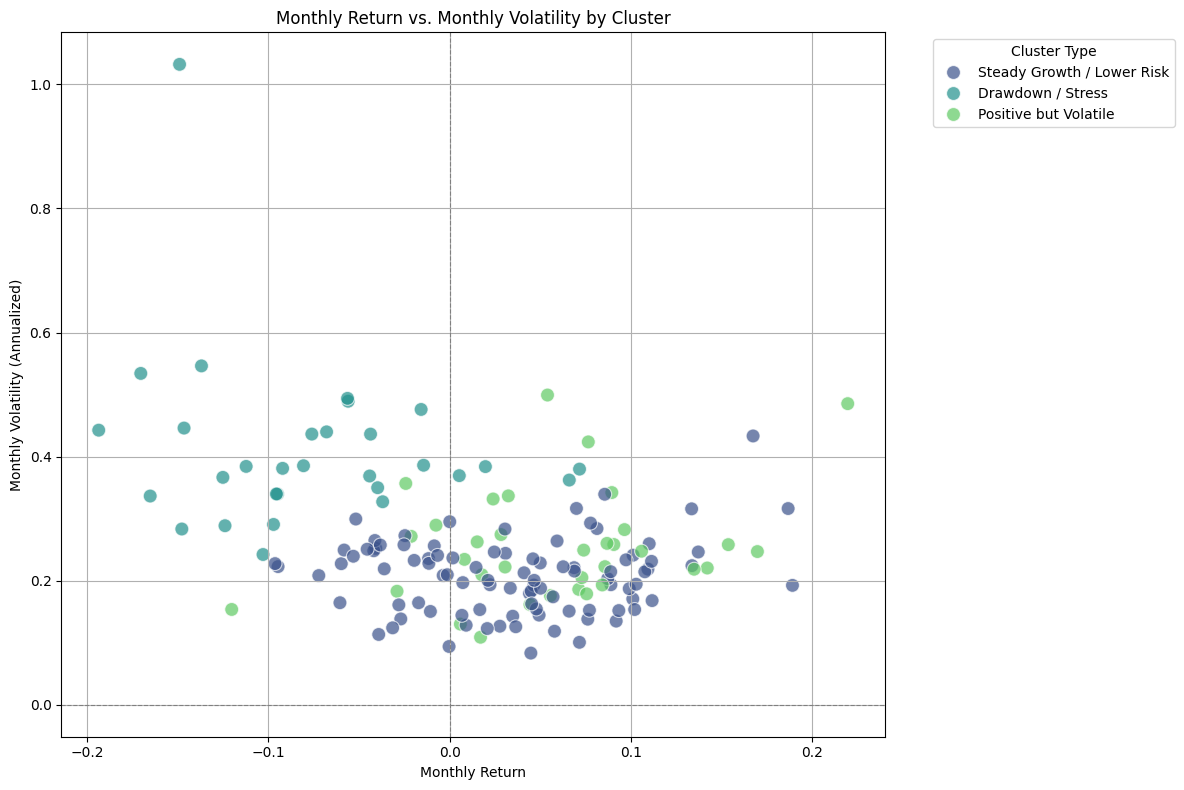

In [ ]:
print("Generating scatter plot of Monthly_Return vs. Monthly_Volatility colored by cluster...")

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_monthly_features,
    x='Monthly_Return',
    y='Monthly_Volatility',
    hue='cluster_name', # Use descriptive cluster names for legend
    palette='viridis', # Choose a color palette
    s=100, # Marker size
    alpha=0.7 # Transparency
)
plt.title('Monthly Return vs. Monthly Volatility by Cluster')
plt.xlabel('Monthly Return')
plt.ylabel('Monthly Volatility (Annualized)')
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(title='Cluster Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Generating scatter plot of Worst_Drawdown vs. Average_Volume_Ratio colored by cluster...


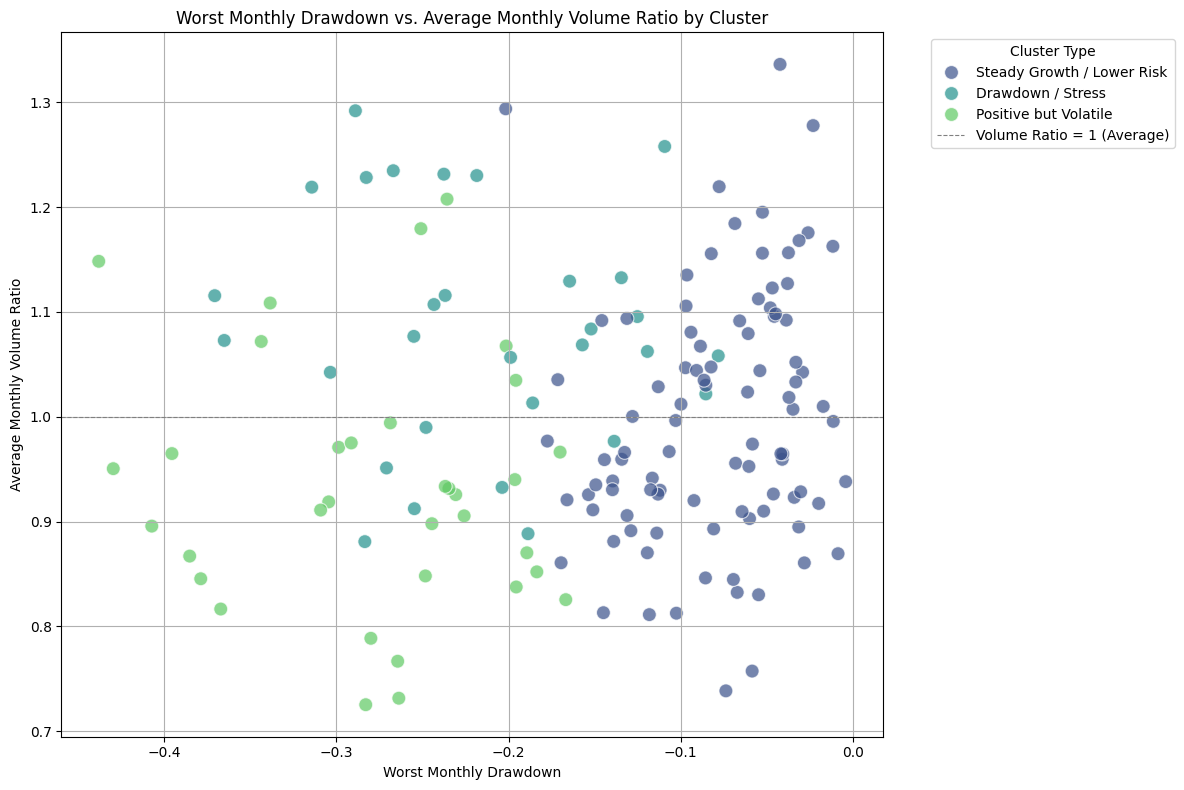

In [ ]:
print("Generating scatter plot of Worst_Drawdown vs. Average_Volume_Ratio colored by cluster...")

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_monthly_features,
    x='Worst_Drawdown',
    y='Average_Volume_Ratio',
    hue='cluster_name',
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Worst Monthly Drawdown vs. Average Monthly Volume Ratio by Cluster')
plt.xlabel('Worst Monthly Drawdown')
plt.ylabel('Average Monthly Volume Ratio')
plt.grid(True)
plt.axhline(1, color='grey', linestyle='--', linewidth=0.8, label='Volume Ratio = 1 (Average)') # Add a line for average volume ratio
plt.legend(title='Cluster Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## SECTION 13 — FINANCIAL FUNDAMENTALS EDA **

This section presents the exploratory data analysis **(EDA) performed on the annual financial fundamentals dataset**. I have examined key financial indicators to better understand the company’s financial performance, profitability, efficiency, and overall financial health over time. **Trend-based visualizations are used** to highlight changes across reporting periods and identify notable patterns

In [ ]:
df_financial_indicators = df_fundamentals_processed.copy()

print("Calculating annual financial indicators...")

# 1. Revenue_Growth: (Current Year Revenue / Previous Year Revenue) - 1
df_financial_indicators['revenue_growth'] = df_financial_indicators['revenue'].pct_change() * 100 # In percentage terms

# 2. Operating_Margin: Operating Income / Revenue
# Handle potential division by zero
df_financial_indicators['operating_margin'] = np.where(
    df_financial_indicators['revenue'] != 0,
    (df_financial_indicators['operating_income'] / df_financial_indicators['revenue']) * 100,
    np.nan
)

# 3. Net_Margin: Net Income / Revenue
df_financial_indicators['net_margin'] = np.where(
    df_financial_indicators['revenue'] != 0,
    (df_financial_indicators['net_income'] / df_financial_indicators['revenue']) * 100,
    np.nan
)



# Calculate Free Cash Flow Margin (Operating Cash Flow - Capital Expenditures) / Revenue
df_financial_indicators['fcf_margin'] = np.where(
    df_financial_indicators['revenue'] != 0,
    ((df_financial_indicators['operating_cash_flow'] - df_financial_indicators['capital_expenditures']) / df_financial_indicators['revenue']) * 100,
    np.nan
)

print("Financial indicators calculated.")
print("First 5 rows with new indicators:")
print(df_financial_indicators.head())

# Store the processed financial indicators dataframe
df_financial_processed = df_financial_indicators.copy()


Calculating annual financial indicators...
Financial indicators calculated.
First 5 rows with new indicators:
   year  revenue  net_income  operating_income  operating_cash_flow  \
0  2011   108249       25922             33790                37529   
1  2012   156508       41733             55241                50856   
2  2013   170910       37037             48999                53666   
3  2014   182795       39510             52503                59713   
4  2015   233715       53394             71230                81266   

   capital_expenditures  free_cash_flow  cash_and_investments  total_debt  \
0                  4260           33269                 81570           0   
1                  8295           42561                121251           0   
2                  8165           45501                146761       16960   
3                  9571           50142                155239       35295   
4                 11247           70019                205666       64462   



Below cells uses a **series of visualizations to examine how Apple’s financial performance** and capital allocation have changed over time. I create **annual trend charts for revenue, operating income, and net income to assess the company’s growth, profitability, and earnings trajectory across multiple** reporting periods. These visualizations help **identify long-term patterns, periods of accelerated growth**, and **potential shifts** in financial performance.

The analysis also **explores** the company’s cash generation capabilities through **operating cash flow and free cash flow trends.** Comparing these measures provides insight into **how effectively Apple converts business activity into available cash**. Annual dividends and share repurchases are visualized to evaluate how the company returns value to shareholders. Together, all these **charts offer a comprehensive view** of operational performance, financial strength, cash flow management, and shareholder-focused capital allocation decisions.

Generating charts for Revenue, Operating Income, and Net Income by year...


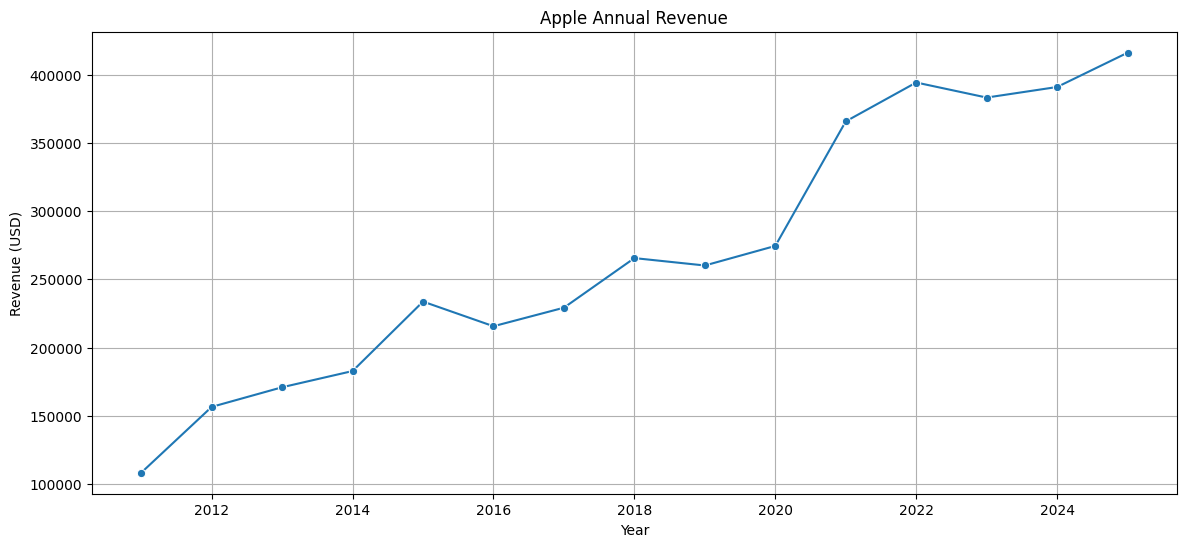

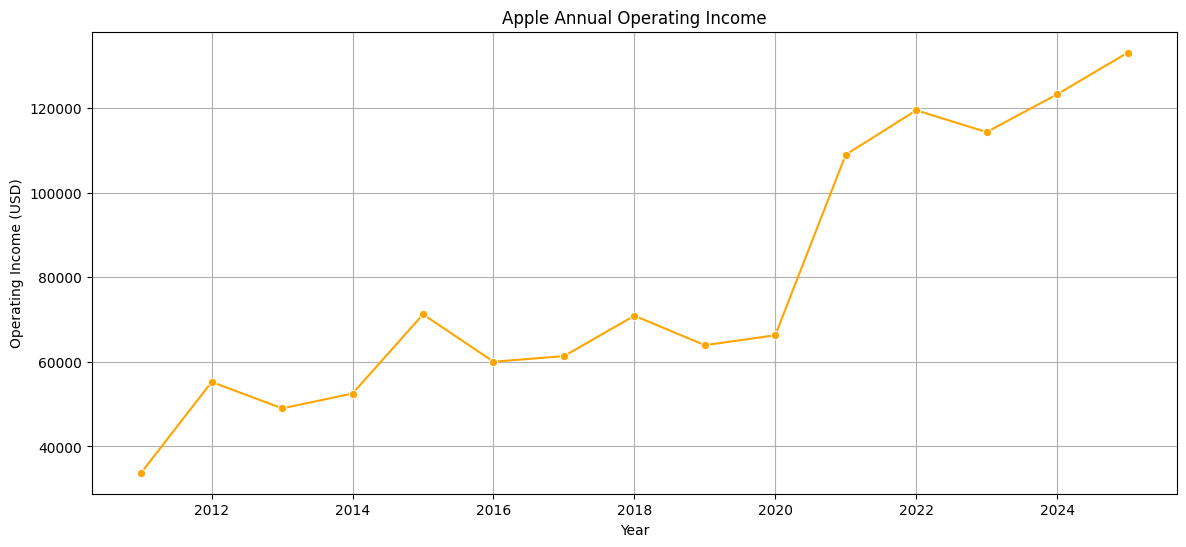

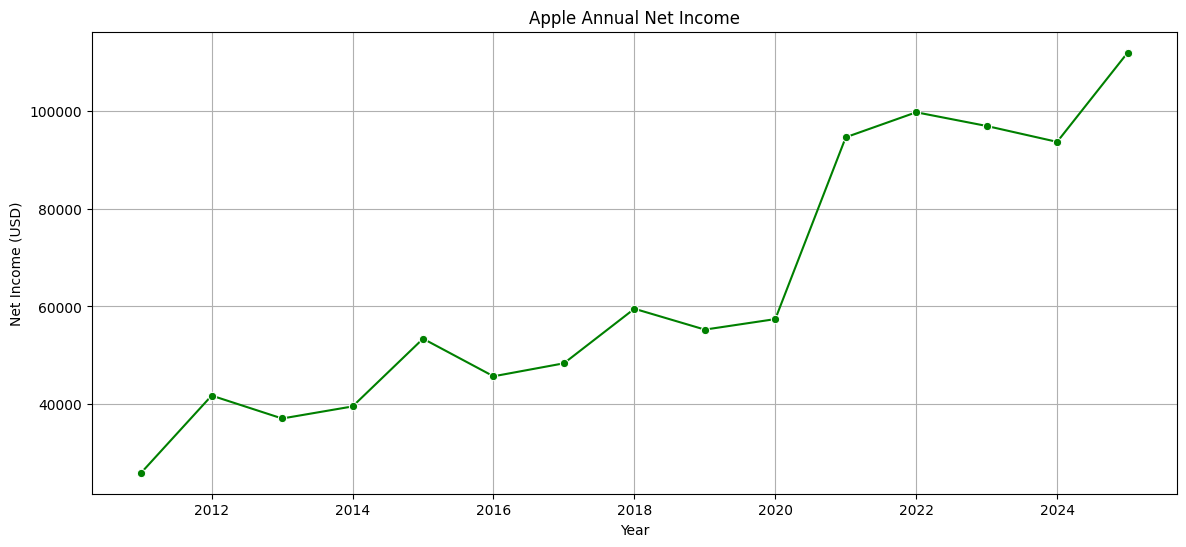

In [ ]:
print("Generating charts for Revenue, Operating Income, and Net Income by year...")

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_financial_processed, x='year', y='revenue', marker='o')
plt.title('Apple Annual Revenue')
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
plt.show()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_financial_processed, x='year', y='operating_income', marker='o', color='orange')
plt.title('Apple Annual Operating Income')
plt.xlabel('Year')
plt.ylabel('Operating Income (USD)')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_financial_processed, x='year', y='net_income', marker='o', color='green')
plt.title('Apple Annual Net Income')
plt.xlabel('Year')
plt.ylabel('Net Income (USD)')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()


Generating charts for Operating Cash Flow and Free Cash Flow by year...


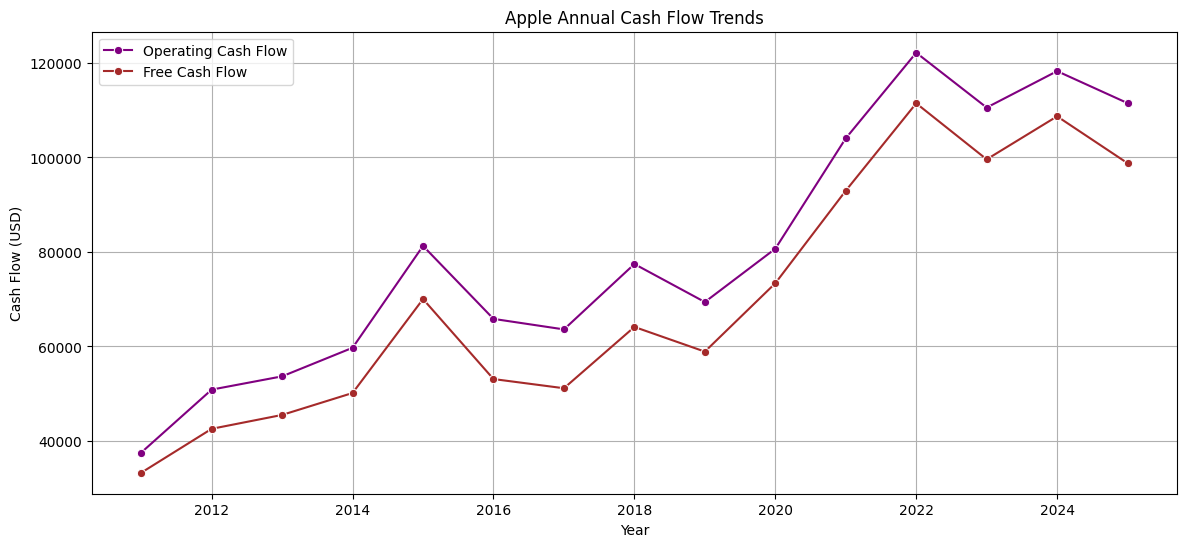

In [ ]:
print("Generating charts for Operating Cash Flow and Free Cash Flow by year...")

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_financial_processed, x='year', y='operating_cash_flow', marker='o', color='purple', label='Operating Cash Flow')
sns.lineplot(data=df_financial_processed, x='year', y='free_cash_flow', marker='o', color='brown', label='Free Cash Flow')
plt.title('Apple Annual Cash Flow Trends')
plt.xlabel('Year')
plt.ylabel('Cash Flow (USD)')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.show()


Generating charts for Dividends and Share Repurchases by year...


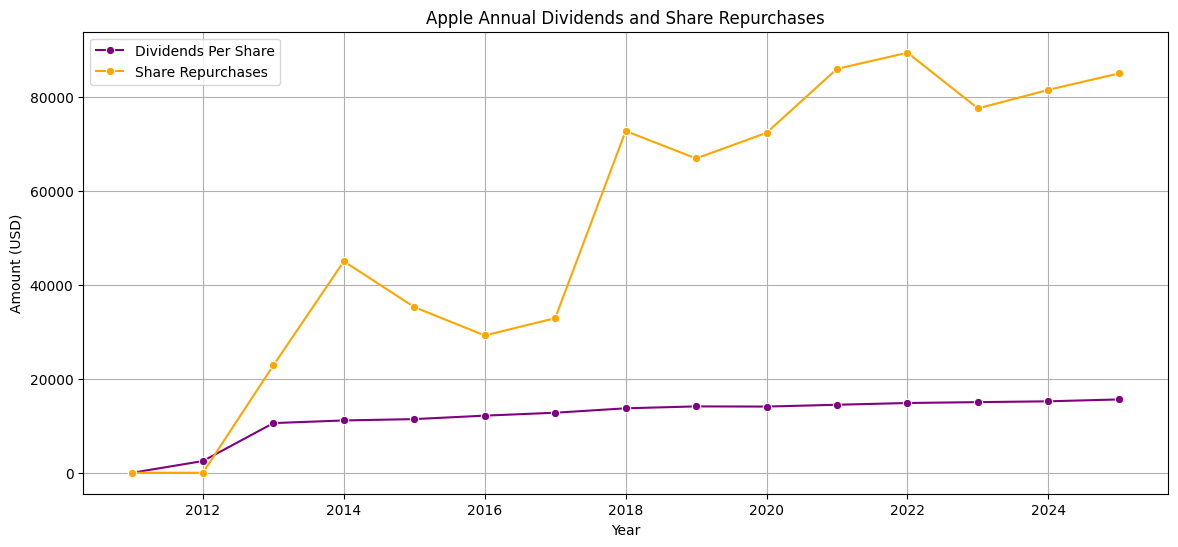

In [ ]:
print("Generating charts for Dividends and Share Repurchases by year...")

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_financial_processed, x='year', y='dividends', marker='o', color='purple', label='Dividends Per Share')
sns.lineplot(data=df_financial_processed, x='year', y='share_repurchases', marker='o', color='orange', label='Share Repurchases')
plt.title('Apple Annual Dividends and Share Repurchases')
plt.xlabel('Year')
plt.ylabel('Amount (USD)')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.show()

## SECTION 14 — ASSUMPTIONS LOG

This is an **assumptions log to document the key decisions, and expectations that underpin** the analysis. I ahve organized each assumption into a **structured format with a unique identifier, category, and potential impact,** making it easier to track important considerations throughout the project lifecycle.

The **assumptions cover several areas, including data quality, data preparation, feature engineering, clustering methodology, financial reporting, and project scope.** By explicitly documenting these assumptions, the analysis becomes more transparent and reproducible, while also helping stakeholders understand the limitations, risks, and context behind the results. This log serves as a reference point for interpreting findings, validating conclusions, and managing potential uncertainties that could influence the overall analysis.

In [ ]:
print("Creating assumptions log...")

# Define the initial assumptions
assumptions_data = {
    'Assumption ID': [
        'A1', 'A2', 'A3', 'A4', 'A5',
        'A6', 'A7', 'A8', 'A9', 'A10'
    ],
    'Category': [
        'Data Quality', 'Data Filtering', 'Data Cleaning', 'Feature Engineering', 'Model Selection',
        'Model Interpretation', 'Clustering Stability', 'Financial Data', 'Project Scope', 'Methodology'
    ],
    'Description': [
        'The provided stock and financial fundamentals datasets are accurate reflections of historical data.',
        'Analysis starts from October 5, 2011, as specified in the project brief.',
        'Missing values in critical columns for daily features are handled by row removal.',
        'Rolling metrics (e.g., 21-day volatility) are appropriate for capturing short-to-medium term market behavior.',
        'K-Means clustering is suitable for identifying distinct market regimes based on the chosen features.',
        'The assigned cluster names accurately represent the underlying characteristics of each market regime.',
        'The clustering solution is reasonably stable across different random initializations.',
        'Financial fundamentals are taken as reported annually and directly comparable year-over-year.',
        'This project is for pattern discovery and descriptive interpretation, not for future price prediction or investment advice.',
        'Statistical significance testing for cluster differences is outside the scope of this project, relying on descriptive analysis.'
    ],
    'Impact': [
        'Inaccurate data would lead to flawed analysis and conclusions.',
        'Excludes earlier historical data which might contain different market conditions.',
        'May reduce the number of observations, especially at the beginning of the time series.',
        'Choice of window size (e.g., 21 days) impacts sensitivity to short-term fluctuations.',
        'K-Means assumes spherical clusters and equal variance, which may not perfectly hold for market data.',
        'Misinterpretation of clusters could lead to incorrect conclusions about market regimes.',
        'Instability would indicate a less reliable and reproducible clustering solution.',
        'Any errors or non-standard reporting in fundamental data would affect financial analysis.',
        'Prevents over-interpretation of results as predictive or prescriptive investment guidance.',
        'Limits the ability to make definitive statistical claims about cluster distinctiveness.'
    ]
}

df_assumptions_log = pd.DataFrame(assumptions_data)

print("Assumptions log created.")
print("First 5 rows of Assumptions Log:")
print(df_assumptions_log.head())


Creating assumptions log...
Assumptions log created.
First 5 rows of Assumptions Log:
  Assumption ID             Category  \
0            A1         Data Quality   
1            A2       Data Filtering   
2            A3        Data Cleaning   
3            A4  Feature Engineering   
4            A5      Model Selection   

                                         Description  \
0  The provided stock and financial fundamentals ...   
1  Analysis starts from October 5, 2011, as speci...   
2  Missing values in critical columns for daily f...   
3  Rolling metrics (e.g., 21-day volatility) are ...   
4  K-Means clustering is suitable for identifying...   

                                              Impact  
0  Inaccurate data would lead to flawed analysis ...  
1  Excludes earlier historical data which might c...  
2  May reduce the number of observations, especia...  
3  Choice of window size (e.g., 21 days) impacts ...  
4  K-Means assumes spherical clusters and equal v...  


## SECTION 15 — LIMITATIONS

coming up


## SECTION 16 — EXECUTIVE SUMMARY

coming up


## SECTION 17 — SAVE OUTPUT FILES
will save key output files as CSVs to preserve intermediate and final results for future use and sharing.

## SECTION 18 — LINKS